In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [2]:
df = pd.read_csv('/content/covid_19_clean_complete.csv')

df.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


In [3]:
df.shape

(49068, 10)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Province/State  14664 non-null  object 
 1   Country/Region  49068 non-null  object 
 2   Lat             49068 non-null  float64
 3   Long            49068 non-null  float64
 4   Date            49068 non-null  object 
 5   Confirmed       49068 non-null  int64  
 6   Deaths          49068 non-null  int64  
 7   Recovered       49068 non-null  int64  
 8   Active          49068 non-null  int64  
 9   WHO Region      49068 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 3.7+ MB


In [5]:
df.isnull().sum()

,0
Province/State,34404
Country/Region,0
Lat,0
Long,0
Date,0
Confirmed,0
Deaths,0
Recovered,0
Active,0
WHO Region,0


In [6]:
df['Date'] = pd.to_datetime(df['Date'])

df.fillna(0, inplace=True)

df.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,0,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,0,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,0,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,0,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,0,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


In [7]:
df['Active'] = (
    df['Confirmed']
    - df['Deaths']
    - df['Recovered']
)

df.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,0,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,0,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,0,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,0,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,0,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


In [8]:
df.describe()

,Lat,Long,Date,Confirmed,Deaths,Recovered,Active
count,49068.000000,49068.000000,49068,4.906800e+04,49068.000000,4.906800e+04,4.906800e+04
mean,21.433730,23.528236,2020-04-24 12:00:00,1.688490e+04,884.179160,7.915713e+03,8.085012e+03
min,-51.796300,-135.000000,2020-01-22 00:00:00,0.000000e+00,0.000000,0.000000e+00,-1.400000e+01
25%,7.873054,-15.310100,2020-03-08 18:00:00,4.000000e+00,0.000000,0.000000e+00,0.000000e+00
50%,23.634500,21.745300,2020-04-24 12:00:00,1.680000e+02,2.000000,2.900000e+01,2.600000e+01
75%,41.204380,80.771797,2020-06-10 06:00:00,1.518250e+03,30.000000,6.660000e+02,6.060000e+02
max,71.706900,178.065000,2020-07-27 00:00:00,4.290259e+06,148011.000000,1.846641e+06,2.816444e+06
std,24.950320,70.442740,NaN,1.273002e+05,6313.584411,5.480092e+04,7.625890e+04


In [9]:
latest = df[df['Date']==df['Date'].max()]

total_confirmed = latest['Confirmed'].sum()
total_deaths = latest['Deaths'].sum()
total_recovered = latest['Recovered'].sum()
total_active = latest['Active'].sum()

print("Confirmed :", total_confirmed)
print("Deaths :", total_deaths)
print("Recovered :", total_recovered)
print("Active :", total_active)

Confirmed : 16480485
Deaths : 654036
Recovered : 9468087
Active : 6358362


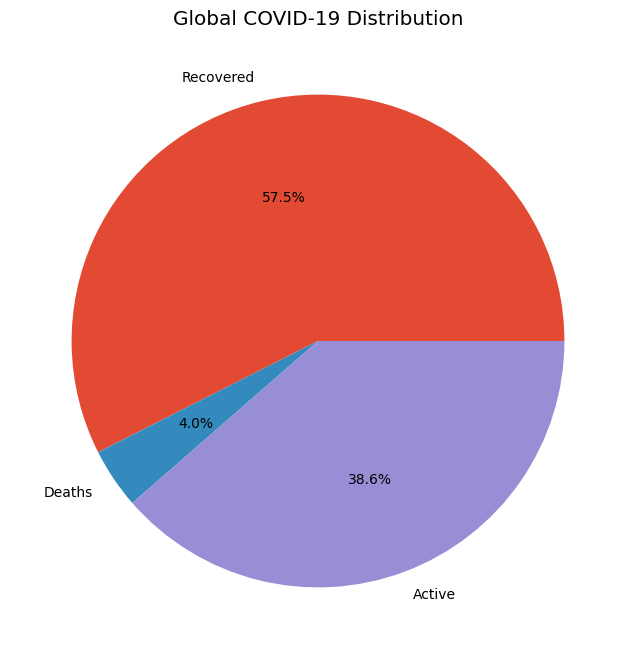

In [10]:
labels = ['Recovered','Deaths','Active']

sizes = [
    total_recovered,
    total_deaths,
    total_active
]

plt.figure(figsize=(8,8))

plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%'
)

plt.title("Global COVID-19 Distribution")

plt.show()

In [11]:
top10 = latest.sort_values(
    by='Confirmed',
    ascending=False
).head(10)

top10[['Country/Region','Confirmed']]

,Country/Region,Confirmed
49030,US,4290259
48835,Brazil,2442375
48936,India,1480073
48992,Russia,816680
49005,South Africa,452529
48963,Mexico,395489
48986,Peru,389717
48854,Chile,347923
49028,United Kingdom,300111
48938,Iran,293606


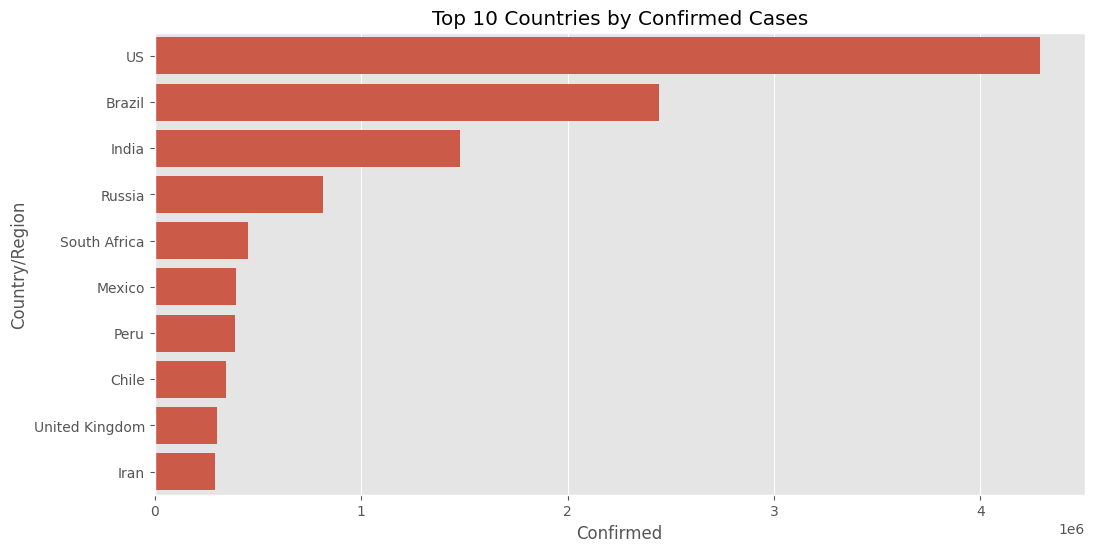

In [12]:
plt.figure(figsize=(12,6))

sns.barplot(
    x='Confirmed',
    y='Country/Region',
    data=top10
)

plt.title(
    'Top 10 Countries by Confirmed Cases'
)

plt.show()

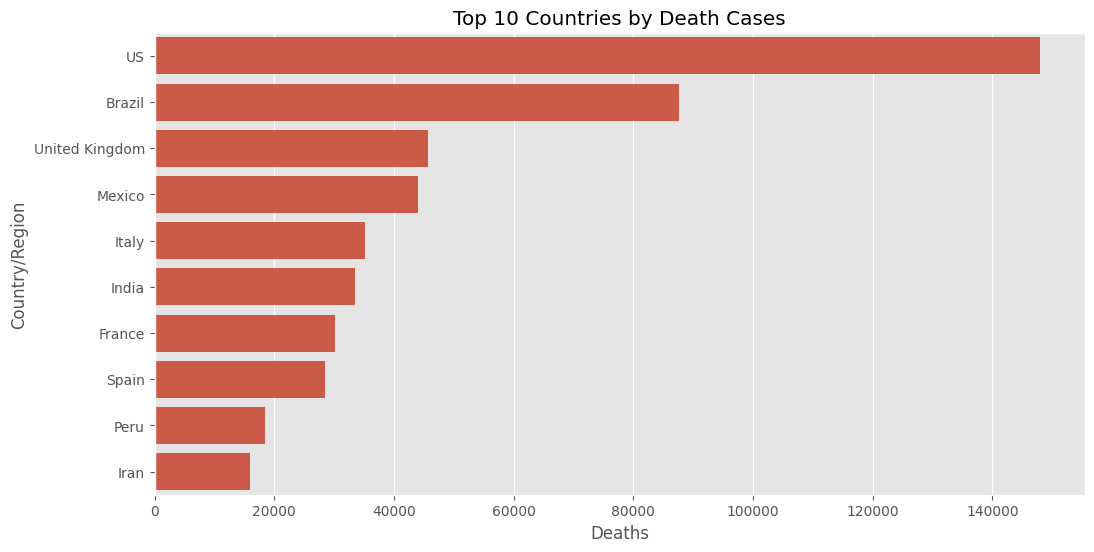

In [13]:
top_deaths = latest.sort_values(
    by='Deaths',
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x='Deaths',
    y='Country/Region',
    data=top_deaths
)

plt.title(
    'Top 10 Countries by Death Cases'
)

plt.show()

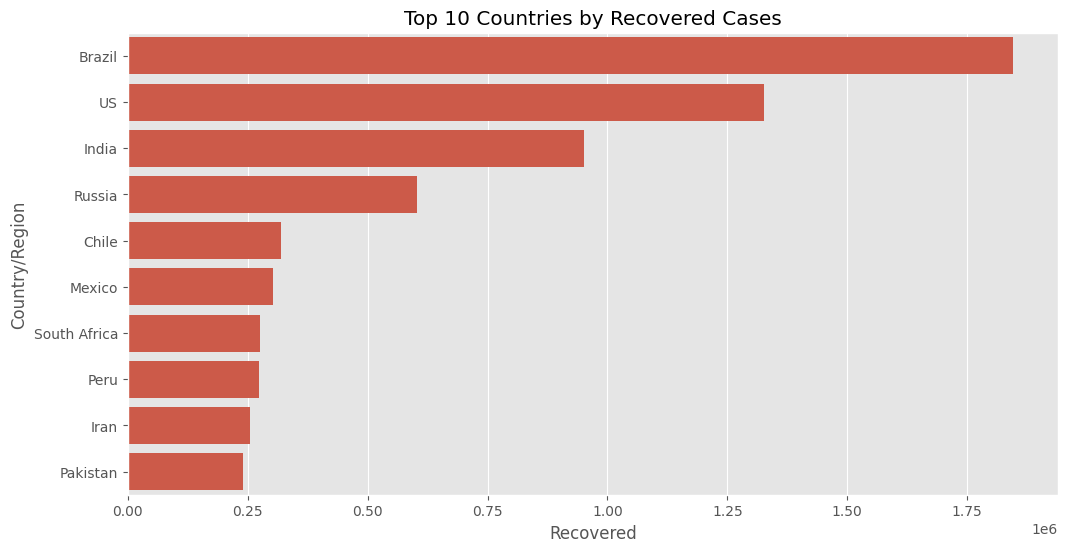

In [14]:
top_recovered = latest.sort_values(
    by='Recovered',
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x='Recovered',
    y='Country/Region',
    data=top_recovered
)

plt.title(
    'Top 10 Countries by Recovered Cases'
)

plt.show()

In [15]:
world = df.groupby(
    'Date'
)[['Confirmed',
   'Deaths',
   'Recovered']].sum().reset_index()

world.head()

,Date,Confirmed,Deaths,Recovered
0,2020-01-22,555,17,28
1,2020-01-23,654,18,30
2,2020-01-24,941,26,36
3,2020-01-25,1434,42,39
4,2020-01-26,2118,56,52


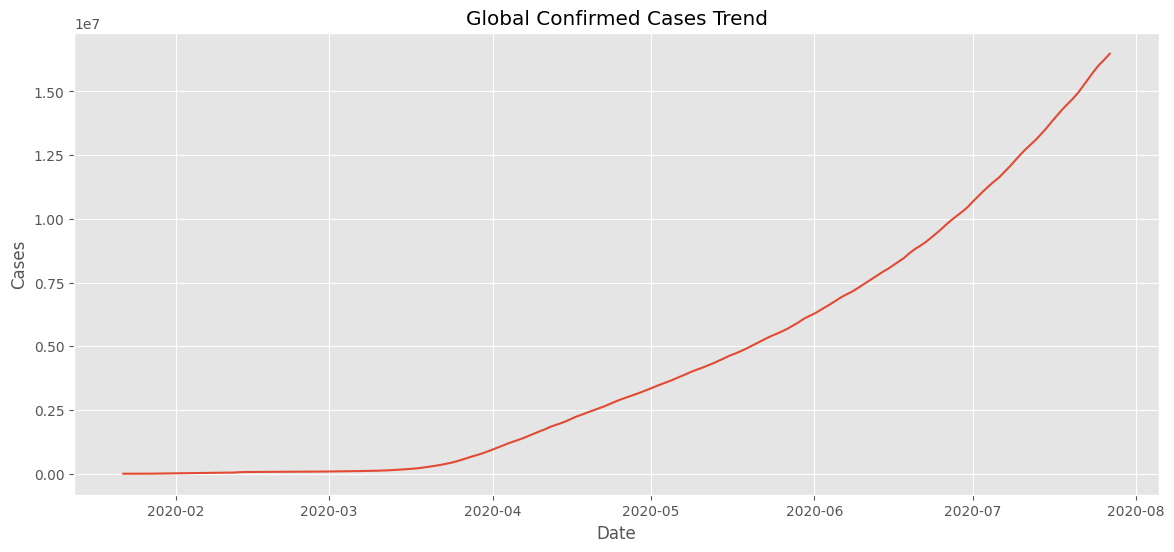

In [16]:
plt.figure(figsize=(14,6))

plt.plot(
    world['Date'],
    world['Confirmed']
)

plt.title(
    'Global Confirmed Cases Trend'
)

plt.xlabel('Date')
plt.ylabel('Cases')

plt.show()

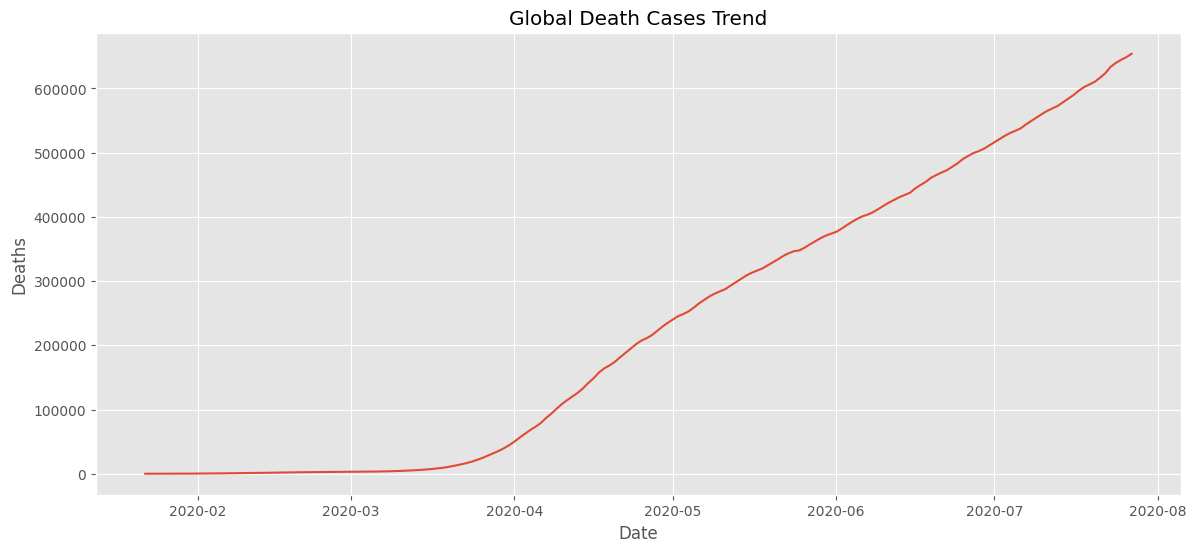

In [17]:
plt.figure(figsize=(14,6))

plt.plot(
    world['Date'],
    world['Deaths']
)

plt.title(
    'Global Death Cases Trend'
)

plt.xlabel('Date')
plt.ylabel('Deaths')

plt.show()

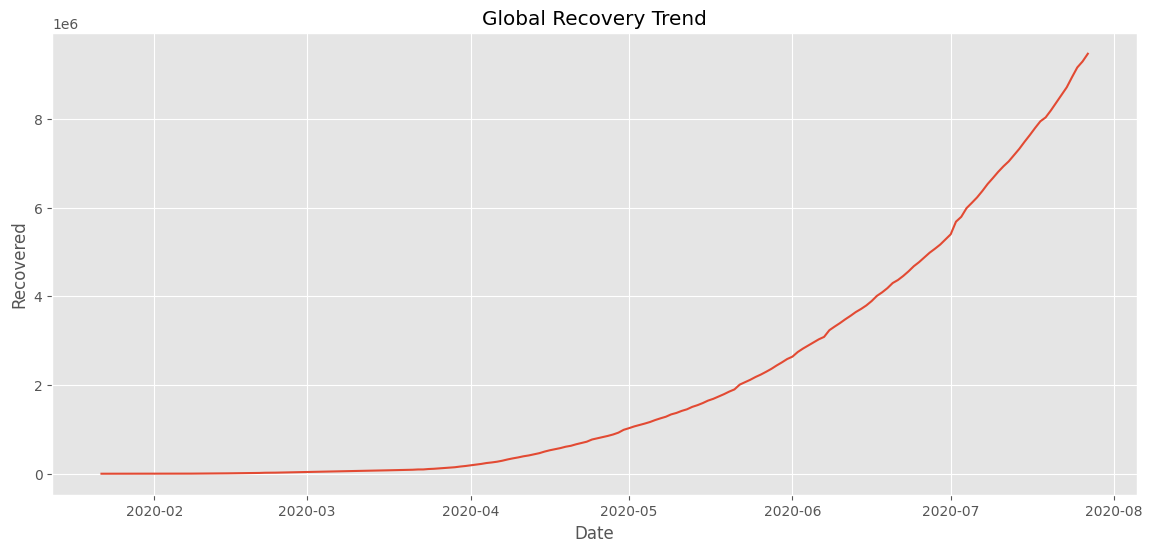

In [18]:
plt.figure(figsize=(14,6))

plt.plot(
    world['Date'],
    world['Recovered']
)

plt.title(
    'Global Recovery Trend'
)

plt.xlabel('Date')
plt.ylabel('Recovered')

plt.show()


In [19]:
world['Daily Cases'] = world[
    'Confirmed'
].diff()

world.head()

,Date,Confirmed,Deaths,Recovered,Daily Cases
0,2020-01-22,555,17,28,NaN
1,2020-01-23,654,18,30,99.0
2,2020-01-24,941,26,36,287.0
3,2020-01-25,1434,42,39,493.0
4,2020-01-26,2118,56,52,684.0


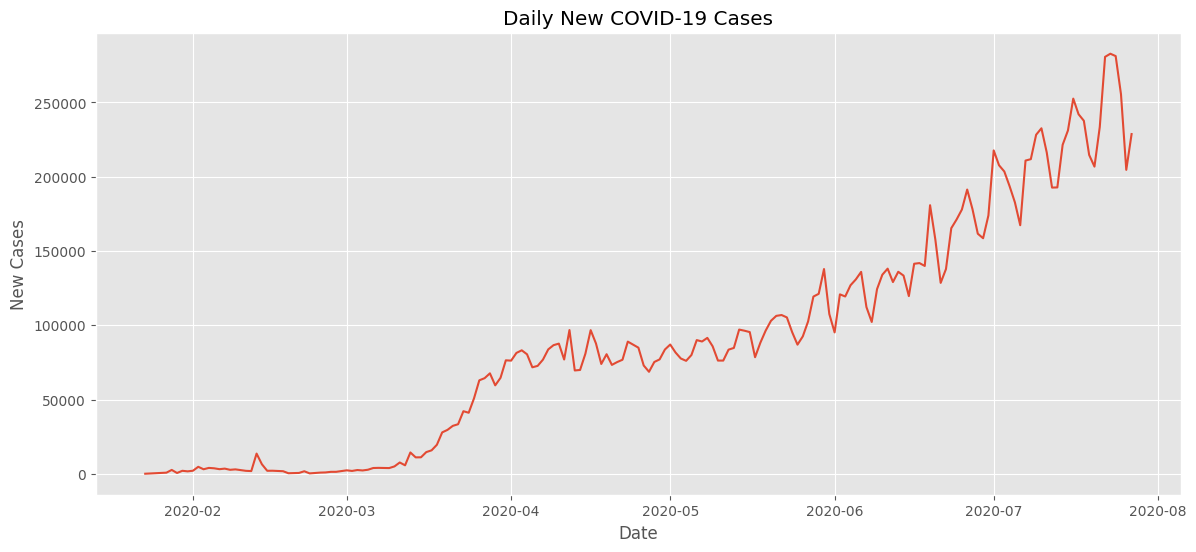

In [20]:
plt.figure(figsize=(14,6))

plt.plot(
    world['Date'],
    world['Daily Cases']
)

plt.title(
    'Daily New COVID-19 Cases'
)

plt.xlabel('Date')
plt.ylabel('New Cases')

plt.show()

In [21]:
region = latest.groupby(
    'WHO Region'
)['Confirmed'].sum().sort_values(
    ascending=False
)

region

,Confirmed
WHO Region,
Americas,8839286
Europe,3299523
South-East Asia,1835297
Eastern Mediterranean,1490744
Africa,723207
Western Pacific,292428


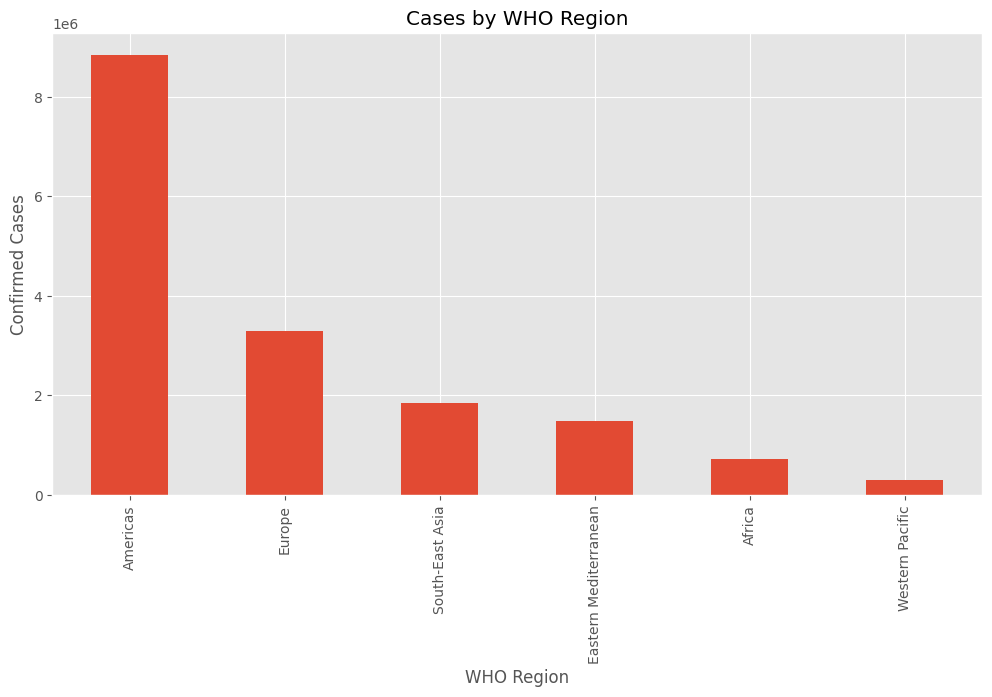

In [22]:
plt.figure(figsize=(12,6))

region.plot(kind='bar')

plt.title(
    'Cases by WHO Region'
)

plt.ylabel('Confirmed Cases')

plt.show()

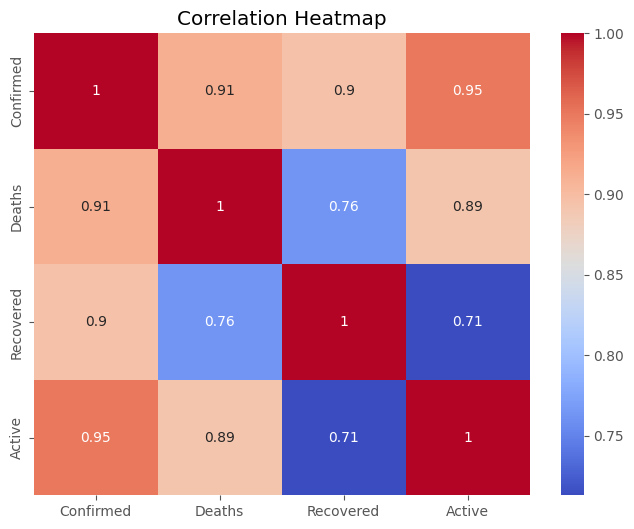

In [23]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[['Confirmed',
        'Deaths',
        'Recovered',
        'Active']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title(
    'Correlation Heatmap'
)

plt.show()